## This code was written by Gabriel Quimbayo Polo & Reviewed by Dr. Leidy Cubillos-Pinilla.

In [4]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.utils import resample
import itertools
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
path = '<path to data>'

data = pd.read_excel(f'{path}')
data.set_index('Subject', inplace=True)

In [16]:
# determine the subjects that are in high entreprenuerial intention group and low entrepreneurial intention group 
# based on the mean of the entrepreneurial intention score of the sample itself

mean_entrepreneurial_intention = data['MeanEntIntention'].mean()

high_entrepreneurial_intention = data[data['MeanEntIntention'] > mean_entrepreneurial_intention].index
low_entrepreneurial_intention = data[data['MeanEntIntention'] <= mean_entrepreneurial_intention].index

print('High entrepreneurial intention:', high_entrepreneurial_intention)
print('Low entrepreneurial intention:', low_entrepreneurial_intention)

High entrepreneurial intention: Index([3, 4, 15, 17, 24, 26, 27, 34, 35, 37, 40, 45, 49, 50, 58, 65, 66, 70,
       75, 76],
      dtype='int64', name='Subject')
Low entrepreneurial intention: Index([1, 5, 8, 12, 18, 28, 29, 32, 42, 43, 54, 56, 59, 60, 61, 62, 67, 68, 69,
       72, 74],
      dtype='int64', name='Subject')


In [20]:
subjects_high = data.loc[high_entrepreneurial_intention]
subjects_low = data.loc[low_entrepreneurial_intention]

# determine latency mean for each group in B1B2 condition

latency_mean_high = subjects_high['P3_B1B2_CenterParietal6_LAT'].mean()
latency_mean_low = subjects_low['P3_B1B2_CenterParietal6_LAT'].mean()

print('Latency mean high:', round(latency_mean_high, 2))
print('Latency mean low:', round(latency_mean_low, 2))

Latency mean high: 414.92
Latency mean low: 390.93


In [2]:
data['CE'] = data[['B_1', 'FirstRT', 'P3_B1_CenterParietal6_LAT']].mean(axis=1)
data['SCE'] = data[['A_1', 'FirstMinusLatterRT', 'P3_B1B2_CenterParietal6_LAT']].mean(axis=1)

# dependent variables
X_vars = ['B_1', 'FirstRT', 'P3_B1_CenterParietal6_LAT', 'CE',
        'A_1', 'FirstMinusLatterRT', 'P3_B1B2_CenterParietal6_LAT', 'SCE']

y_vars = ['MeanEntIntention', 'MeanEntPassion']

# covariates
cov_vars = ['Education', 'EntrepreneurshipCourse']

# mediation variables
M_vars = ['MOpportunityRecognition1', 'MeanEntPassion']


In [3]:
# Initialize results DataFrame
linear_results = pd.DataFrame(columns=[
    'X_Variable', 'Y_Variable', 'Covariates', 'Significance'
])

In [4]:
# Linear regression

def linear(df, x_var, y_var, covariates):

    X = df[[x_var] + covariates]
    X = sm.add_constant(X)
    y = df[y_var]

    model = sm.OLS(y, X).fit()
    
    # Store both p-value and significance
    pvalue = model.pvalues[x_var]

    return {
        'X_Variable': x_var,
        'Y_Variable': y_var,
        'Covariates': covariates,
        'Significance': pvalue < 0.05
    }

In [ ]:
# Run linear regression for all combinations of x_vars and y_vars
for x_var, y_var in itertools.product(x_vars, y_vars):
    for covariates in [[], cov_vars[:1], cov_vars]:
        result = linear(data, x_var, y_var, covariates)
        linear_results = pd.concat([linear_results, pd.DataFrame([result])], ignore_index=True)

linear_results.to_excel('linear_results_ET2.xlsx', index=False)

In [21]:
ET_file = pd.read_excel('linear_results_ET.xlsx')

## Mediation

In [4]:
# Convert relevant columns to numeric
all_variables = X_vars + y_vars + M_vars + cov_vars
for var in all_variables:
    if var in data.columns:
        data[var] = pd.to_numeric(data[var], errors='coerce')

In [5]:
# Initialize results DataFrame
mediation_results = pd.DataFrame(columns=[
    'X_Variable', 'Y_Variable', 'M_Variable', 'Covariates', 'Significance', 'p-value_x', 'p-value_m'
])


In [6]:
# Mediation analysis

# Custom mediation analysis function
def mediation_analysis(df, x_var, y_var, m_var, covariates, n_iterations=100):

    if df.empty:
        return None

    # Prepare the data for the mediator model
    X_mediator = sm.add_constant(df[[x_var] + covariates])
    y_mediator = df[m_var]

    # Fit the mediator model (M ~ X + covariates)
    mediator_model = sm.OLS(y_mediator, X_mediator).fit()

    # Prepare the data for the outcome model
    X_outcome = sm.add_constant(df[[x_var, m_var] + covariates])

    y_outcome = df[y_var]

    # Fit the outcome model (Y ~ X + M + covariates)
    outcome_model = sm.OLS(y_outcome, X_outcome).fit()

    # Calculate direct and indirect effects
    a = mediator_model.params[x_var]  # Path a
    b = outcome_model.params[m_var]   # Path b
    indirect_effect = a * b
    c_prime = outcome_model.params[x_var]  # Path c'
    total_effect = c_prime + indirect_effect
    proportion_mediated = indirect_effect / total_effect if total_effect != 0 else np.nan

    # Bootstrap to get confidence intervals for the indirect effect
    bootstrap_indirect_effects = np.zeros(n_iterations)
    for i in range(n_iterations):
        df_boot = resample(df)
        
        X_mediator_boot = sm.add_constant(df_boot[[x_var] + covariates])
        y_mediator_boot = df_boot[m_var]
        mediator_model_boot = sm.OLS(y_mediator_boot, X_mediator_boot).fit()

        X_outcome_boot = sm.add_constant(df_boot[[x_var, m_var] + covariates])
        y_outcome_boot = df_boot[y_var]
        outcome_model_boot = sm.OLS(y_outcome_boot, X_outcome_boot).fit()

        a_boot = mediator_model_boot.params.get(x_var, 0)
        b_boot = outcome_model_boot.params.get(m_var, 0)
        bootstrap_indirect_effects[i] = a_boot * b_boot

    lower_bound = np.percentile(bootstrap_indirect_effects, 2.5)
    upper_bound = np.percentile(bootstrap_indirect_effects, 97.5)

    # Determine significance
    significance = 'FALSE'
    if mediator_model.pvalues.get(x_var, 1) < 0.05 and outcome_model.pvalues.get(m_var, 1) < 0.05:
        significance = 'TRUE'

    # Return results as a dictionary
    return {
        'X_Variable': x_var,
        'Y_Variable': y_var,
        'M_Variable': m_var,
        'Covariates': covariates,
        'Significance': significance,
        'p-value_x': mediator_model.pvalues.get(x_var, 1),
        'p-value_m': outcome_model.pvalues.get(m_var, 1),
    }


In [7]:
# Perform mediation analysis for each combination of variables

# y_var = 'MeanEntIntention'
# m_var = 'MOpportunityRecognition1'

for x_var, y_var, m_var in itertools.product(X_vars, y_vars, M_vars):
    for covariates in [[], cov_vars[:1], cov_vars]:
        result_ = mediation_analysis(data, x_var, y_var, m_var, covariates)
        mediation_results = pd.concat([mediation_results, pd.DataFrame([result_])], ignore_index=True)

In [8]:
mediation_results.to_excel('../Outputs/med_pvalues.xlsx', index=False)

In [31]:
data_ET = pd.read_excel('ET.xlsx')

pattern = r'^(A|B)_(\d+)$'

# Filter rows where the variable is significant
significant_df = data_ET[data_ET['Significance'] == True]

# Extract the variables of interest based on the pattern and matching number
filtered_df = significant_df[significant_df['X_Variable'].str.match(pattern)].copy()

# Separate out the number part of the variable for matching A_# with B_#
filtered_df['Variable_Prefix'], filtered_df['Number'] = zip(*filtered_df['X_Variable'].str.extract(pattern).values)

# Filter for pairs that match in number across A_# and B_#
significant_pairs = filtered_df[filtered_df.duplicated(subset='Number', keep=False)]

In [33]:
a_variables = significant_pairs[significant_pairs['Variable_Prefix'] == 'A']
b_variables = significant_pairs[significant_pairs['Variable_Prefix'] == 'B']

# Find common numbers that appear in both A_# and B_# sets
common_numbers = set(a_variables['Number']).intersection(set(b_variables['Number']))

# Filter the original DataFrame to retain only rows with the common numbers
common_a_b_variables = significant_pairs[significant_pairs['Number'].isin(common_numbers)]

In [34]:
common_a_b_variables.to_excel('common_a_b_variables.xlsx', index=False)

In [9]:
df_neural_b1 = mediation_results[mediation_results['X_Variable'].str.contains('B1', na=False)].copy()
df_neural_b1b2 = mediation_results[mediation_results['X_Variable'].str.contains('B1B2', na=False)].copy()

df_neural_b1['X_Base'] = df_neural_b1['X_Variable'].str.replace('B1', '', regex=False)
df_neural_b1b2['X_Base'] = df_neural_b1b2['X_Variable'].str.replace('B1B2', '', regex=False)

# Merge both datasets based on Y_Variable, M_Variable, and Covariates to find the same configuration
df_neural_combined = pd.merge(df_neural_b1, df_neural_b1b2, 
                              on=['X_Base', 'Y_Variable', 'M_Variable', 'Covariates', 'Significance'], 
                              suffixes=('_B1', '_B1B2'))

vars_bins_significant = df_neural_combined[df_neural_combined['Significance'] == True]

In [10]:
desired_set = set(M_vars)

# Filter vars_bins_significant to include only rows with M_Variable in M_vars
filtered_vars = vars_bins_significant[vars_bins_significant['M_Variable'].isin(M_vars)]

# Group by X_Variable_B1 and aggregate M_Variable into a set
grouped = filtered_vars.groupby('X_Variable_B1')['M_Variable'].apply(set).reset_index()

# Select X_Variable_B1 where the set of M_Variable matches the desired set
matching_X_Variables = grouped[grouped['M_Variable'] == desired_set]['X_Variable_B1'].unique()

# Display the matching X_Variable_B1 values
desired_rows = vars_bins_significant[vars_bins_significant['X_Variable_B1'].isin(matching_X_Variables)]
desired_rows.to_excel('new_vars_bins_significant.xlsx', index=False)

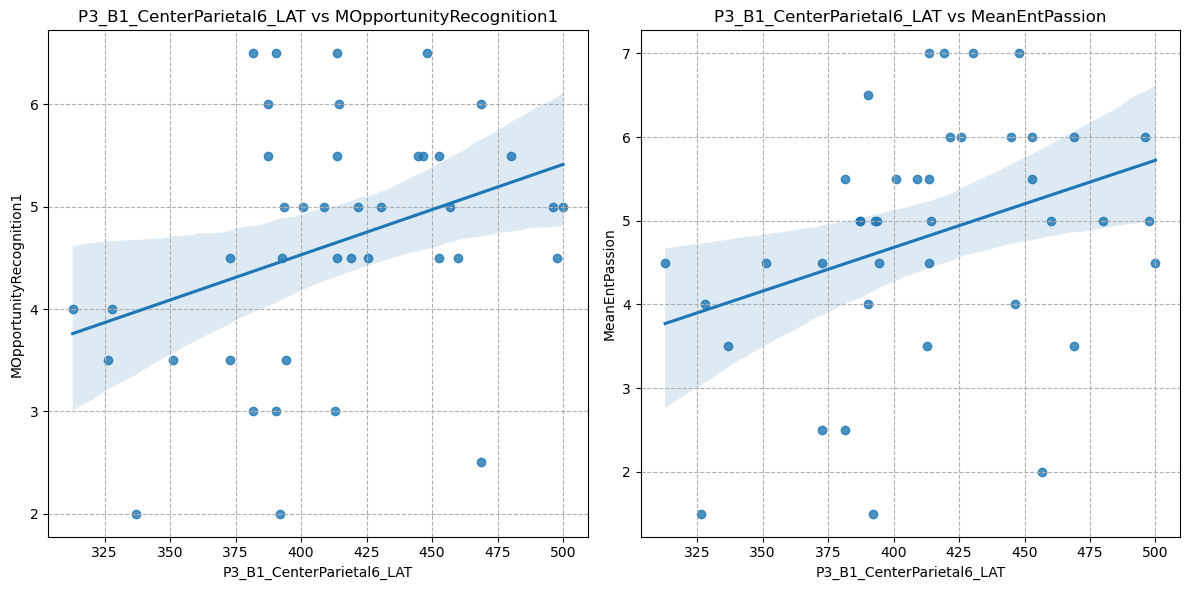

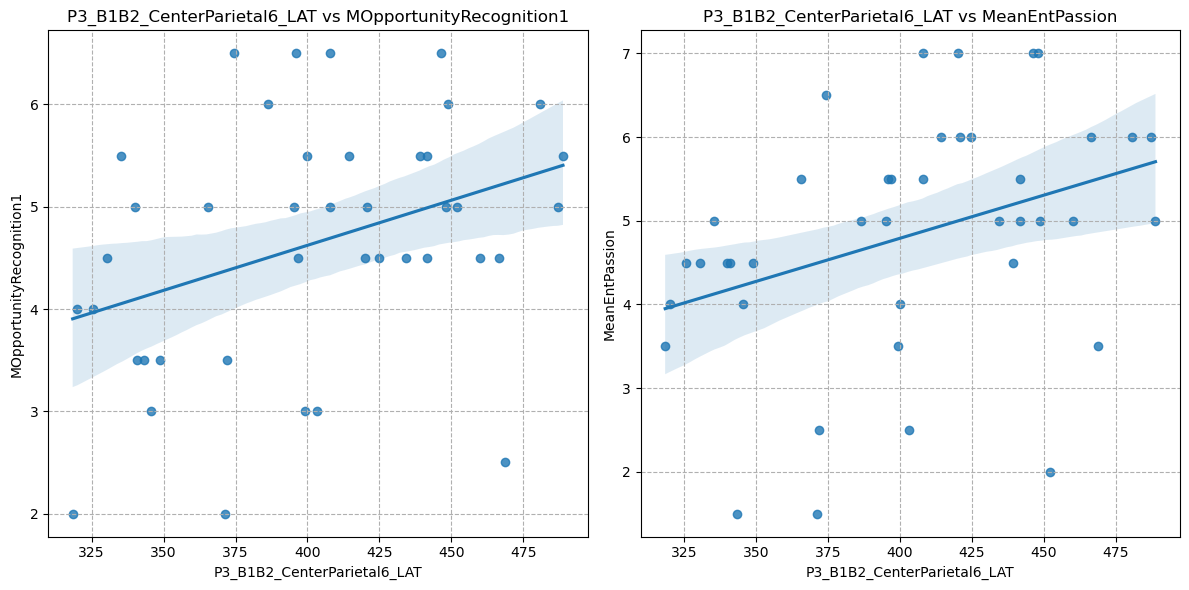

In [16]:
# To focus on the variables of interest, I'll filter the dataframe to only include 'Delta_CP2_B1', 'Delta_CP2_B1B2', 'MOpportunityRecognition1', and 'MeanEntPassion'.
# Then, I'll generate correlation plots between 'Delta_CP2_B1' and the mediators, as well as 'Delta_CP2_B1B2' and the mediators.

df = pd.read_excel('data_AMS.xlsx')

# Extract relevant columns
df_filtered = df[['P3_B1_CenterParietal6_MA', 'P3_B1B2_CenterParietal6_MA', 
                  'P3_B1_CenterParietal6_LAT', 'P3_B1B2_CenterParietal6_LAT',
                  'ET11', 'ET45', 'MeanEntIntention',
                  'MOpportunityRecognition1', 'MeanEntPassion']].dropna()

# Plotting relationships between 'Delta_CP2_B1' and the mediators
plt.figure(figsize=(12, 6))

# First subplot: Delta_CP2_B1 vs MOpportunityRecognition1
plt.subplot(1, 2, 1)
sns.regplot(x='P3_B1_CenterParietal6_LAT', y='MOpportunityRecognition1', data=df_filtered)
plt.title('P3_B1_CenterParietal6_LAT vs MOpportunityRecognition1')
plt.grid(linestyle='--')

# Second subplot: Delta_CP2_B1 vs MeanEntPassion
plt.subplot(1, 2, 2)
sns.regplot(x='P3_B1_CenterParietal6_LAT', y='MeanEntPassion', data=df_filtered)
plt.title('P3_B1_CenterParietal6_LAT vs MeanEntPassion')
plt.grid(linestyle='--')

plt.tight_layout()
plt.show()

# Plotting relationships between 'Delta_CP2_B1B2' and the mediators
plt.figure(figsize=(12, 6))

# First subplot: Delta_CP2_B1B2 vs MOpportunityRecognition1
plt.subplot(1, 2, 1)
sns.regplot(x='P3_B1B2_CenterParietal6_LAT', y='MOpportunityRecognition1', data=df_filtered)
plt.title('P3_B1B2_CenterParietal6_LAT vs MOpportunityRecognition1')
plt.grid(linestyle='--')

# Second subplot: Delta_CP2_B1B2 vs MeanEntPassion
plt.subplot(1, 2, 2)
sns.regplot(x='P3_B1B2_CenterParietal6_LAT', y='MeanEntPassion', data=df_filtered)
plt.title('P3_B1B2_CenterParietal6_LAT vs MeanEntPassion')

plt.tight_layout()
plt.grid(linestyle='--')
plt.show()


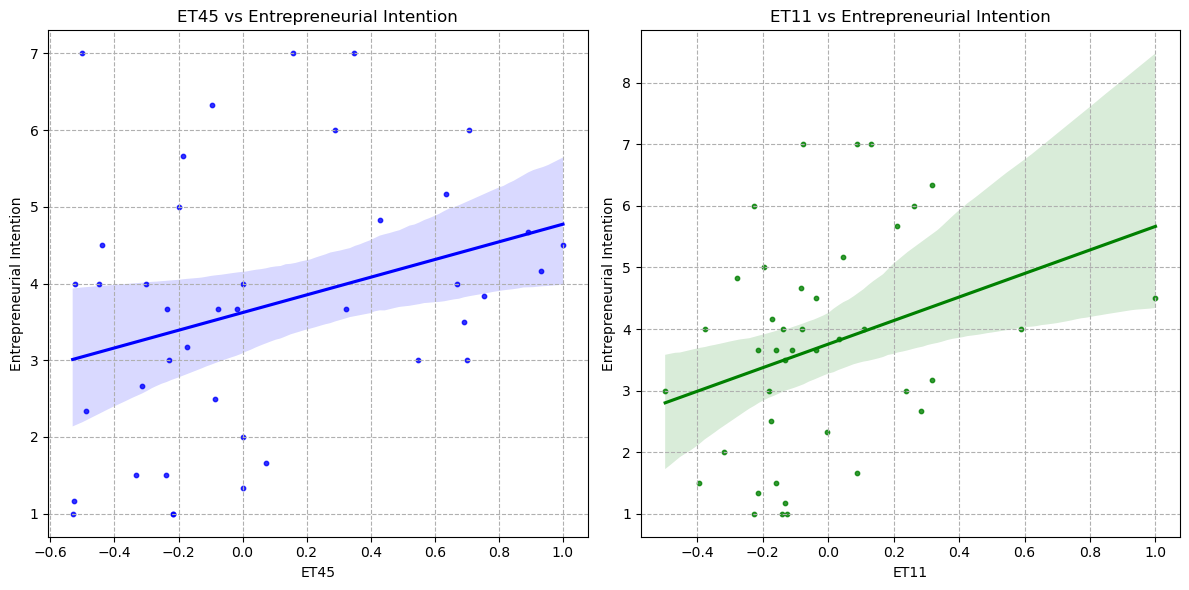

In [19]:
plt.figure(figsize=(12, 6))

# ET45 vs Entrepreneurial Intention with regression line
plt.subplot(1, 2, 1)
sns.regplot(x='ET45', y='MeanEntIntention', scatter_kws={'s':10}, color='blue', data=df_filtered)
plt.title('ET45 vs Entrepreneurial Intention')
plt.xlabel('ET45')
plt.ylabel('Entrepreneurial Intention')
plt.grid(linestyle='--')

# ET11 vs Entrepreneurial Intention with regression line
plt.subplot(1, 2, 2)
sns.regplot(x='ET11', y='MeanEntIntention', scatter_kws={'s':10}, color='green', data=df_filtered)
plt.title('ET11 vs Entrepreneurial Intention')
plt.xlabel('ET11')
plt.ylabel('Entrepreneurial Intention')
plt.grid(linestyle='--')

plt.tight_layout()
plt.show()